Fountain Single Optimization Example
======================================
This notebook runs and visualizes a single fountain sequence design using
Ledidi + Semifreddo on one genomic window, serving as an interactive example
of the multi-model fountain optimization setup.

Background
----------
Fountain structures appear as elevated signal along the antidiagonal of a Hi-C
contact map, reflecting convergent chromatin looping. To design sequences that
induce fountain-like structures, we optimize a central 50-bin (102,400 bp)
editable region using a cone-shaped antidiagonal mask as the target signal.

Multi-model setup
-----------------
Four Akita v2 ensemble models (models 0–3) are used simultaneously during
optimization via a StackingDesignWrapper, which concatenates their outputs
along dim=1 to produce a (batch, 4, N_triu) tensor. The optimization target
is built as the per-model baseline prediction with the fountain mask overlaid,
stacked in the same format. After optimization, predictions from all 8 models
(including held-out models 4–7) are shown to assess generalization.

Semifreddo approximation
------------------------
Instead of passing the full 1.3 Mb sequence through the convolutional tower at
every Ledidi step, MultiBinSemifreddoLedidiWrapper recomputes only a 60-bin
padded window around the 50 editable bins and splices those activations back
into the cached full-sequence tower output. This gives identical predictions
(Pearson R ≈ 1.0 vs. full model) at a fraction of the compute cost.

## Imports

In [1]:
import os
import sys

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sys.path.append(os.path.abspath("/home1/smaruj/akita_pytorch/"))
sys.path.insert(0, "/home1/smaruj/ledidi/ledidi/")
sys.path.insert(0, "/home1/smaruj/ledidi/wrappers/")
sys.path.insert(0, os.path.abspath("/home1/smaruj/akita_semifreddo/"))

from akita.model import SeqNN
from ledidi import Ledidi
from wrappers import DesignWrapper

from semifreddo.semifreddo import MultiBinSemifreddoLedidiWrapper
from utils.losses_utils import LocalL1Loss, MultiHeadLocalL1Loss
from utils.data_utils import from_upper_triu
from utils.model_utils import StackingDesignWrapper

## Config

All paths and hyperparameters are defined here.    
`FOUNTAIN_STRENGTH` and `FOUNTAIN_TAG` must match what was used in
`generate_fountains_optimization_files.py` to load the correct target and mask.    
`L` is the Ledidi regularisation weight balancing edit sparsity vs. target fidelity.    

In [2]:
FOLD  = 0

CHROM = "chrX"
START = 46927872
END   = 48238592

STEM  = f"{CHROM}_{START}_{END}"

NUM_MODELS = 4

SEQ_BASE_DIR = (
    "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/"
    "analysis/flat_regions"
)
FOUNTAIN_DIR = (
    "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/"
    "optimizations/fountains"
)
MASK_DIR = (
    "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/"
    "optimizations/feature_masks"
)
MODEL_PATH_PATTERN = (
    "/home1/smaruj/akita_pytorch/models/trained_from_scratch/Vian2018_Bcells/checkpoints/"
    "Akita_v2_mouse_Vian2018_Bcells_model{model_idx}_from_scratch.pth"
)
PWM_PATH = "/home1/smaruj/ledidi_akita/data/pwm/MA0139.1.meme"

FOUNTAIN_STRENGTH = 0.5   # must match the tag used in generate_fountains_optimization_files.py
FOUNTAIN_TAG      = f"pos{str(FOUNTAIN_STRENGTH).replace('.', 'p')}"

SEQ_PATH    = f"{SEQ_BASE_DIR}/mouse_sequences/fold{FOLD}/{STEM}_X.pt"
TOWER_PATHS = [
    f"{SEQ_BASE_DIR}/mouse_tower_outputs/model{m}/fold{FOLD}/{STEM}_tower_out.pt"
    for m in range(NUM_MODELS)
]
TARGET_PATH = f"{FOUNTAIN_DIR}/targets/fountain_{FOUNTAIN_TAG}/fold{FOLD}/{STEM}_target.pt"
MASK_PATH   = f"{MASK_DIR}/fountain_{FOUNTAIN_TAG}_mask.pt"

CENTER_BIN_MAP = 256
N_EDIT_BINS    = 50
CONTEXT_BINS   = 5
SPLICE_BUFFER  = 2
BIN_SIZE       = 2048

# ── Optimisation hyperparameters ──────────────────────────────────────────────
L              = 0.01
MAX_ITER       = 2000
EARLY_STOPPING = 2000

# ── Visualisation ─────────────────────────────────────────────────────────────
VMIN, VMAX = -0.6, 0.6
CMAP       = 'RdBu_r'

N_TRIU = 130305
MAP_SIZE  = 512
NUM_DIAGS = 2

## Load models

Only models 0–3 are loaded here — these are the optimization models.
Models 4–7 (held-out) are loaded later in Cell 8 for evaluation only,
keeping GPU memory usage lower during the optimization step.

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

models = []
for model_idx in range(NUM_MODELS):
    m = SeqNN()
    m.load_state_dict(torch.load(
        MODEL_PATH_PATTERN.format(model_idx=model_idx),
        map_location=device, weights_only=True
    ))
    m.to(device).eval()
    models.append(m)
    print(f"Model {model_idx} loaded")

Device: cuda:0
Model 0 loaded
Model 1 loaded
Model 2 loaded
Model 3 loaded


## Load sequence, towers, target

`X`   : full one-hot encoded genomic sequence (1, 4, 1,310,720)     
`towers`  : one cached conv tower output per model (1, 128, 640), pre-computed by generate_fountains_optimization_files.py     
`target`  : stacked per-model targets (1, 4, N_triu), where each of the 4 slices is that model's baseline prediction with the fountain cone mask overlaid at the specified strength

In [4]:
X      = torch.load(SEQ_PATH,    weights_only=True).to(device)   # (1, 4, L)
towers = [
    torch.load(tp, weights_only=True).to(device)                  # (1, 128, 640)
    for tp in TOWER_PATHS
]
target = torch.load(TARGET_PATH, weights_only=True).to(device)   # (1, 4, N_triu)

print(f"X shape      : {X.shape}")
print(f"Tower shapes : {[t.shape for t in towers]}")
print(f"Target shape : {target.shape}")

X shape      : torch.Size([1, 4, 1310720])
Tower shapes : [torch.Size([1, 128, 640]), torch.Size([1, 128, 640]), torch.Size([1, 128, 640]), torch.Size([1, 128, 640])]
Target shape : torch.Size([1, 4, 130305])


## Build `MultiBinSemifreddoLedidiWrappers` + `DesignWrapper`

In [5]:
sf_wrappers = [
    MultiBinSemifreddoLedidiWrapper(
        model                   = m,
        precomputed_full_output = tower,
        full_X                  = X,
        center_bin              = CENTER_BIN_MAP,
        n_edit_bins             = N_EDIT_BINS,
        context_bins            = CONTEXT_BINS,
        splice_buffer           = SPLICE_BUFFER,
        cropping_applied        = 64,
    )
    for m, tower in zip(models, towers)
]

combined_model = StackingDesignWrapper(sf_wrappers)

MultiBinSemifreddoLedidiWrapper:
  editable bins (map space) : 231–280
  editable bp               : 604,160–706,560
  conv-tower window bp      : 593,920–716,800
  splice range (tower space): 293–346
MultiBinSemifreddoLedidiWrapper:
  editable bins (map space) : 231–280
  editable bp               : 604,160–706,560
  conv-tower window bp      : 593,920–716,800
  splice range (tower space): 293–346
MultiBinSemifreddoLedidiWrapper:
  editable bins (map space) : 231–280
  editable bp               : 604,160–706,560
  conv-tower window bp      : 593,920–716,800
  splice range (tower space): 293–346
MultiBinSemifreddoLedidiWrapper:
  editable bins (map space) : 231–280
  editable bp               : 604,160–706,560
  conv-tower window bp      : 593,920–716,800
  splice range (tower space): 293–346


In [6]:
sf0    = sf_wrappers[0]
X_edit = X[:, :, sf0.edit_bp_start:sf0.edit_bp_end]   # (1, 4, 50*2048)
print(f"Editable bp range  : {sf0.edit_bp_start:,} – {sf0.edit_bp_end:,}")
print(f"X_edit shape       : {X_edit.shape}")

Editable bp range  : 604,160 – 706,560
X_edit shape       : torch.Size([1, 4, 102400])


## Sanity check — Pearson R per model

In [7]:
for model_idx, (m, sf) in enumerate(zip(models, sf_wrappers)):
    with torch.no_grad():
        y_full = m(X)
        y_sf   = sf(X_edit)
    r, _ = pearsonr(y_full.cpu().flatten().numpy(), y_sf.cpu().flatten().numpy())
    print(f"Model {model_idx}  Pearson R (full vs Semifreddo): {r:.6f}  (expect 1.0)")

/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


Model 0  Pearson R (full vs Semifreddo): 1.000000  (expect 1.0)
Model 1  Pearson R (full vs Semifreddo): 1.000000  (expect 1.0)
Model 2  Pearson R (full vs Semifreddo): 1.000000  (expect 1.0)
Model 3  Pearson R (full vs Semifreddo): 1.000000  (expect 1.0)


## Build loss

`LocalL1Loss` is applied independently to each of the 4 model heads and summed.   
The scale factor `(N_triu / K)` normalizes for the fraction of the map covered
by the fountain mask, so the loss magnitude is comparable to a full-map loss.   
Using a lambda rather than a `nn.Module` class keeps the setup concise since
no additional state is needed beyond the single shared `LocalL1Loss` instance.

In [8]:
fountain_mask = torch.load(MASK_PATH, weights_only=True).to(device)

The combined model output is `(batch, 4, N_triu)`; `LocalL1Loss` is applied
identically across all 4 heads. We pass the same mask for each head by
wrapping it in a per-model `MultiHeadLocalL1Loss` below.

In [9]:
multi_loss = MultiHeadLocalL1Loss(
    mask      = fountain_mask,
    n_triu    = N_TRIU,
    n_models  = NUM_MODELS,
    reduction = 'sum',
).to(device)

## Run Ledidi

`fit_transform` returns the best generated sequence (lowest total loss) and a
history dict containing per-iteration `input_loss`, `output_loss`, `total_loss`,
and edit positions. Early stopping triggers if no improvement is seen for
`EARLY_STOPPING` consecutive iterations.

In [10]:
ledidi_optimizer = Ledidi(
    combined_model,
    shape               = X_edit.shape[1:],     # (4, 50*2048)
    input_loss          = torch.nn.L1Loss(reduction='sum'),
    output_loss         = multi_loss,
    batch_size          = 1,
    l                   = L,
    max_iter            = MAX_ITER,
    early_stopping_iter = EARLY_STOPPING,
    return_history      = True,
    verbose             = True,
).cuda()

In [11]:
generated_seq, history = ledidi_optimizer.fit_transform(X_edit, target)

iter=I	input_loss=0.0	output_loss=3.236e+05	total_loss=3.236e+05	time=0.0
iter=100	input_loss=1.85e+04	output_loss=1.784e+05	total_loss=1.803e+05	time=28.99
iter=200	input_loss=1.796e+04	output_loss=1.651e+05	total_loss=1.669e+05	time=28.92
iter=300	input_loss=1.88e+04	output_loss=1.619e+05	total_loss=1.637e+05	time=28.94
iter=400	input_loss=2.017e+04	output_loss=1.617e+05	total_loss=1.637e+05	time=28.95
iter=500	input_loss=2.13e+04	output_loss=1.596e+05	total_loss=1.617e+05	time=28.95
iter=600	input_loss=2.224e+04	output_loss=1.588e+05	total_loss=1.611e+05	time=28.95
iter=700	input_loss=2.282e+04	output_loss=1.588e+05	total_loss=1.611e+05	time=28.94
iter=800	input_loss=2.321e+04	output_loss=1.575e+05	total_loss=1.598e+05	time=28.93
iter=900	input_loss=2.36e+04	output_loss=1.6e+05	total_loss=1.624e+05	time=28.94
iter=1000	input_loss=2.384e+04	output_loss=1.558e+05	total_loss=1.582e+05	time=28.94
iter=1100	input_loss=2.392e+04	output_loss=1.569e+05	total_loss=1.593e+05	time=28.94
iter=1

## Evaluate — predictions before and after (models 0–7)

Plot 1 (1×2): model 0 before and target — establishes the baseline flat region and the desired antidiagonal cone target for reference.

Plot 2 (1×8): post-optimization predictions for all 8 models.
Models 0–3 were used in optimization; models 4–7 are held-out.
Comparing the two groups visually shows whether the designed sequence generalizes across the ensemble.

In [12]:
# Reconstruct full sequence with edits applied to the central bin
X_generated_full = X.clone()
X_generated_full[
    :, :, sf0.edit_bp_start:sf0.edit_bp_end
] = generated_seq

In [13]:
ALL_MODELS   = 8

In [14]:
# Load held-out models 4–7
models_4_7 = []
for model_idx in range(4, ALL_MODELS):
    m = SeqNN()
    m.load_state_dict(torch.load(
        MODEL_PATH_PATTERN.format(model_idx=model_idx),
        map_location=device, weights_only=True
    ))
    m.to(device).eval()
    models_4_7.append(m)
    print(f"Model {model_idx} loaded")

all_models = models + models_4_7   # 0–3 already loaded, append 4–7

Model 4 loaded
Model 5 loaded
Model 6 loaded
Model 7 loaded


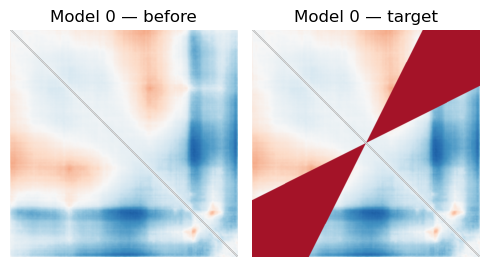

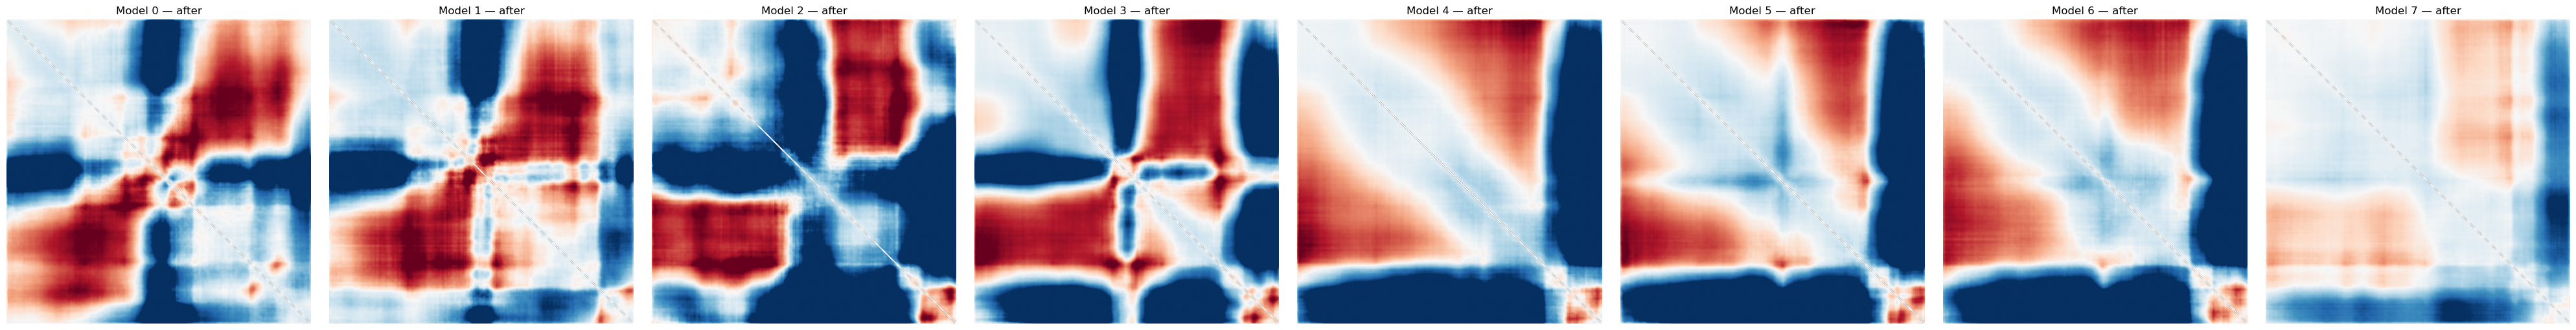

In [15]:
with torch.no_grad():
    y_before_0 = models[0](X).cpu().numpy().squeeze()

map_before_0 = from_upper_triu(y_before_0, MAP_SIZE, NUM_DIAGS)
map_target_0 = from_upper_triu(target[0, 0, :].cpu().numpy(), MAP_SIZE, NUM_DIAGS)

fig, axes = plt.subplots(1, 2, figsize=(5, 3))
axes[0].imshow(map_before_0, vmin=VMIN, vmax=VMAX, cmap=CMAP)
axes[0].set_title("Model 0 — before")
axes[0].axis('off')
axes[1].imshow(map_target_0, vmin=VMIN, vmax=VMAX, cmap=CMAP)
axes[1].set_title("Model 0 — target")
axes[1].axis('off')
plt.tight_layout()
plt.show()

# ── Plot 2: after optimization for all 8 models ───────────────────────────────
fig, axes = plt.subplots(1, ALL_MODELS, figsize=(5 * ALL_MODELS, 5))

for model_idx, m in enumerate(all_models):
    with torch.no_grad():
        y_after = m(X_generated_full).cpu().numpy().squeeze()
    map_after = from_upper_triu(y_after, MAP_SIZE, NUM_DIAGS)
    axes[model_idx].imshow(map_after, vmin=VMIN, vmax=VMAX, cmap=CMAP)
    axes[model_idx].set_title(f"Model {model_idx} — after")
    axes[model_idx].axis('off')

plt.tight_layout()
plt.show()

<Figure size 800x800 with 0 Axes>

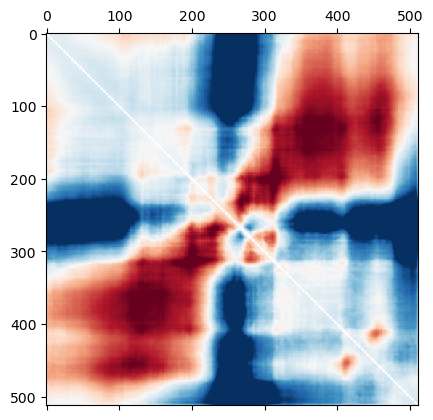

<Figure size 800x800 with 0 Axes>

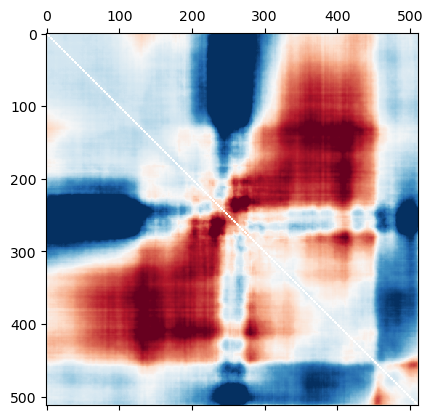

<Figure size 800x800 with 0 Axes>

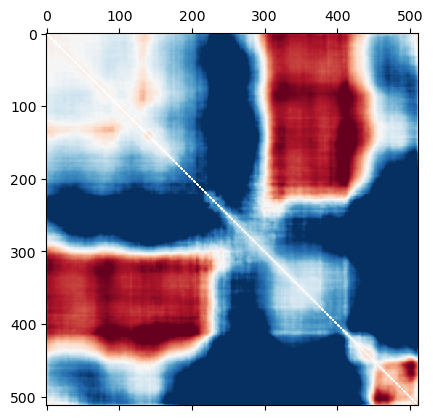

<Figure size 800x800 with 0 Axes>

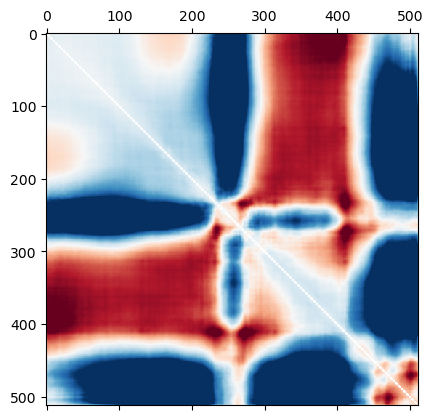

<Figure size 800x800 with 0 Axes>

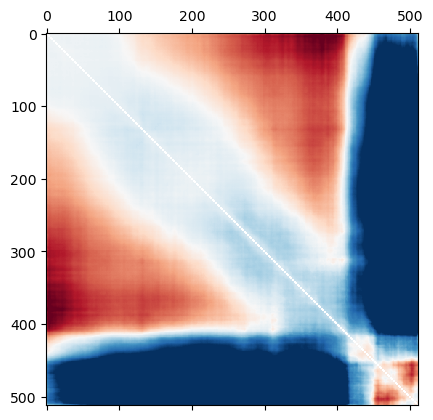

<Figure size 800x800 with 0 Axes>

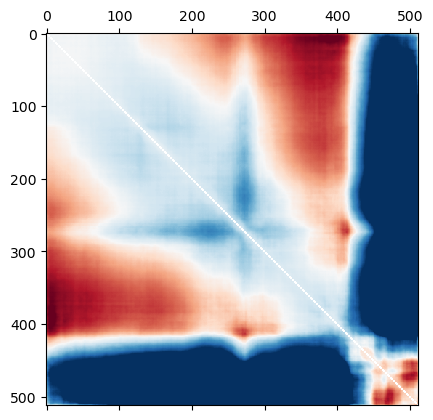

<Figure size 800x800 with 0 Axes>

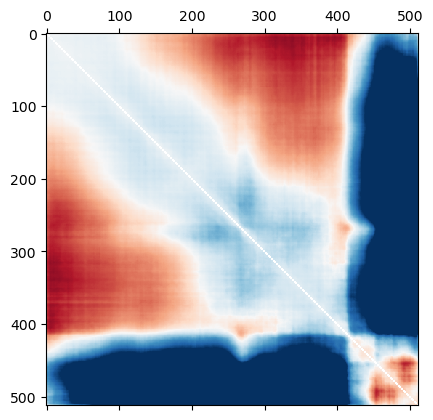

<Figure size 800x800 with 0 Axes>

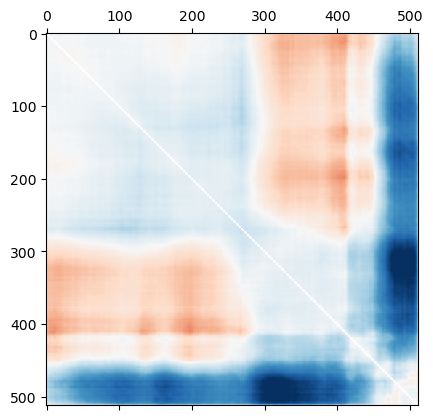

In [20]:
for model_idx, m in enumerate(all_models):
    with torch.no_grad():
        y_after = m(X_generated_full).cpu().numpy().squeeze()
    map_after = from_upper_triu(y_after, MAP_SIZE, NUM_DIAGS)
    
    
    plt.figure(figsize=(8, 8))
    plt.matshow(map_after.astype(np.float16), cmap='RdBu_r', vmin=-0.6, vmax=0.6)
    # plt.colorbar()
    plt.savefig(f"./../plots/map_after_model{model_idx}.svg", format='svg')
    plt.show()